# HIPÓTESIS 2: "El precio de los alojamientos con pocas reseñas es más alto que el de los que tienen muchas."

La lógica detrás de esto suele ser que los "anfitriones novatos" o con propiedades nuevas tienden a sobrevalorar su piso o no tienen el precio optimizado, mientras que los que tienen muchas reseñas (veteranos) ajustan precios para mantener la ocupación.

In [30]:
# Importaciones de librerías y carga del dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv("../src/data/df_2025_limpio.csv")

## 1. Análisis de la Variable price (Precio)
El objetivo es analizar cómo se comporta el dinero en el dataset. Buscamos entender la dispersión.

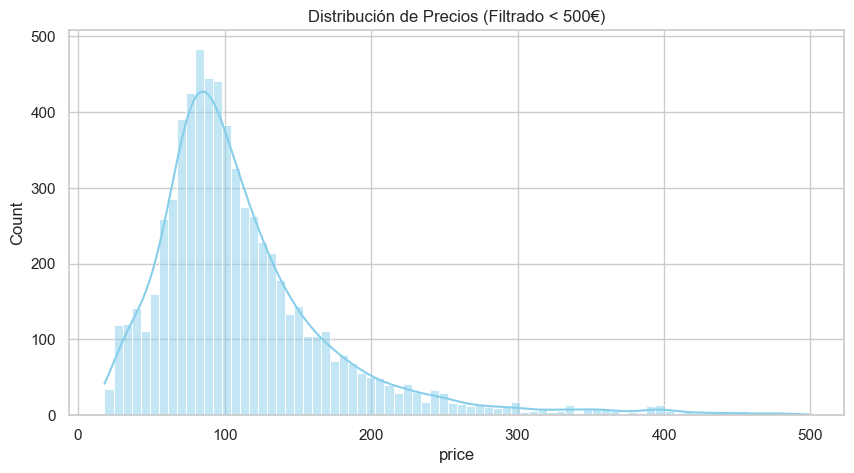

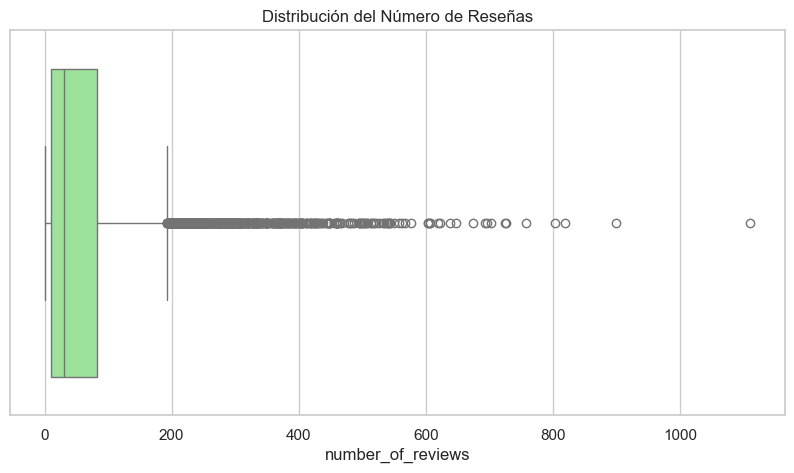

              price  number_of_reviews
count   6861.000000        6861.000000
mean     199.602973          65.558956
std      885.409832          92.460037
min       18.000000           1.000000
25%       75.000000          10.000000
50%       99.000000          30.000000
75%      137.000000          83.000000
max    21911.000000        1110.000000


In [31]:
# 1. Histograma de precios (limitamos a 500 para ver mejor el grueso de los datos)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] < 500]['price'], kde=True, color='skyblue')
plt.title('Distribución de Precios (Filtrado < 500€)')
plt.show()

# 2. Boxplot de reseñas
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['number_of_reviews'], color='lightgreen')
plt.title('Distribución del Número de Reseñas')
plt.show()

# 3. Resumen estadístico
print(df[['price', 'number_of_reviews']].describe())

### Análisis univariante: precio
- **El precio típico:** El valore central (mediana) es de 99€. Es preferible usar este dato antes que la media (199€), ya que la media está "inflada" por unos pocos alojamientos de lujo.
- **Presencia de Outliers:** Existe un valor máximo de 21,911€. Esto indica que existen propiedades excepcionales o errores de carga que podrían sesgar los promedios en análisis posteriores.
- **Rango común:** El 75% de los alojamientos cuesta menos de 137€, lo que sitúa a la gran mayoría en un rango de precio moderado.


### Análisis univariante: reseñas
- **Volumen de actividad:** El alojamiento promedio tiene unas 30 reseñas (mediana).
- **Definición de "Pocas reseñas":** El primer cuartil (25%) nos indica que una parte significativa de los alojamientos tiene 10 reseñas o menos. Este será nuestro grupo de control para la hipótesis.
- **Concentración:** Existe un sesgo importante; hay muchísimos alojamientos con pocas reseñas y muy pocos "superventas" (el máximo es 1,100 reseñas).

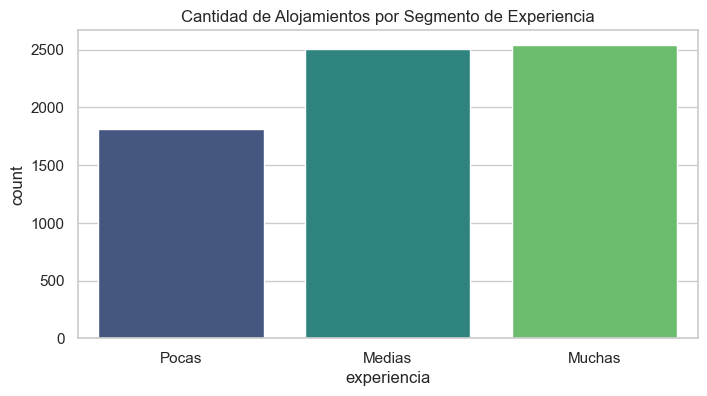

In [39]:
# Voy a agrupar por número de reseñas en grupos para el análisis posterior(1) 
cortes = [0, 10, 50, df['number_of_reviews'].max()]
etiquetas = ['Pocas', 'Medias', 'Muchas']
df['experiencia'] = pd.cut(df['number_of_reviews'], bins=cortes, labels=etiquetas, include_lowest=True)

# Gráfico de barras para ver cuántos hay en cada grupo
plt.figure(figsize=(8, 4))
sns.countplot(x='experiencia', data=df, palette='viridis')
plt.title('Cantidad de Alojamientos por Segmento de Experiencia')
plt.show()

Tenemos una muestra sana. Tenemos casi la misma cantidad de alojamientos en "Medias" y "Muchas", y un grupo sólido de "Pocas". Esto hace que cualquier conclusión que saquemos sea estadísticamente fiable.

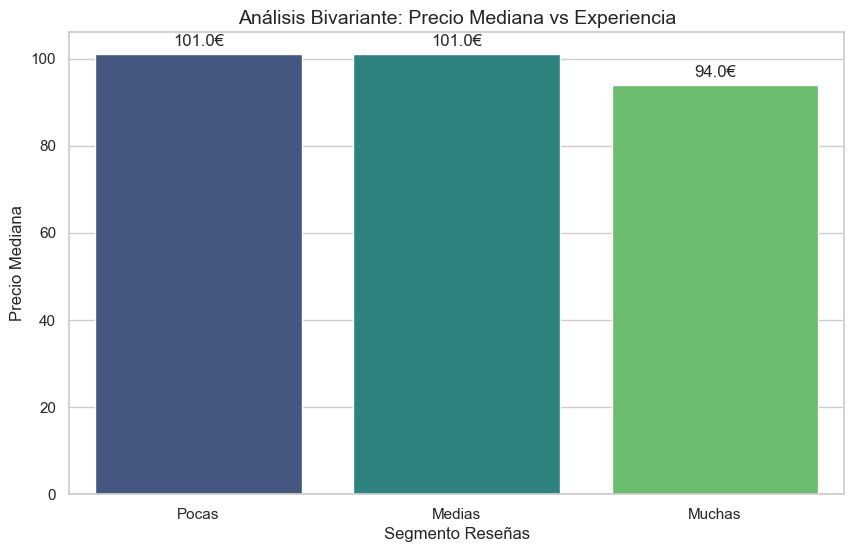

In [35]:
# 2. Crear la tabla resumen asegurando que 'Segmento Reseñas' sea una COLUMNA ( con reset_index)
tabla_grafico = df.groupby('Segmento Reseñas', observed=False)['price'].median().reset_index()
tabla_grafico.columns = ['Segmento Reseñas', 'Precio Mediana']

# 3. Dibujar el gráfico usando esa tabla
plt.figure(figsize=(10, 6))
plot = sns.barplot(
    data=tabla_grafico, 
    x='Segmento Reseñas', 
    y='Precio Mediana', 
    palette='viridis'
)

# 4. Añadir etiquetas de datos encima de las barras
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.1f') + '€', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Análisis Bivariante: Precio Mediana vs Experiencia', fontsize=14)
plt.show()

In [46]:
# Separo en mis tres grupos según sus etiquetas y utilizo solo los números de la columna de precio
df.groupby('categoria_resenas')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
categoria_resenas,,,,,,,,
Pocas,1816.0,348.122247,1419.910112,18.0,75.0,101.0,144.0,10014.0
Medias,2503.0,169.294447,664.352939,22.0,77.0,101.0,141.0,10000.0
Muchas,2542.0,123.344611,468.262422,19.0,72.0,94.0,128.0,21911.0


### Análisis bivariante 
Comparando una variable categórica (los tres grupos de reseñas) con una numérica (las medianas del precio).
- **Diferencia de precios:** Destacamos que el grupo de "Pocas reseñas" tiene una mediana de 101€, mientras que el grupo de "Muchas" baja a 94€.
- **Impacto en los Promedios:** La diferencia es aún más notable en la media (348€ vs. 123€), lo que indica que los alojameintos más caros y exclusivos suelen tener pocas reseñas.

Aunque se confirma la relación, la debilidad de la correlación sugiere que el precio está influenciado por otras variables de mayor peso, como el tipo de alojamiento o la ubicación. Como siguiente paso, se realiza un análisis multivariante para observar si los alojamientos con pocas reseñas son mayoritariamente 'Casas completas' frente a 'Habitaciones privadas'.

### Análisis multivariante:  
*¿La diferencia de precio se debe realmente a las reseñas o hay algo más escondido?*  

El último paso sería ver si ese precio de 101€ de los de "Pocas" se debe a que son casi todos "Casas completas". Vamos a sacar una tabla que cruce **Categoría de Reseñas + Room Type + Precio**.

In [48]:
# Cruzamos las categorías de reseñas con el tipo de habitación
tabla_multi = df.groupby(['categoria_resenas', 'room_type'])['price'].median().unstack()
print(tabla_multi)

room_type          Entire home/apt  Hotel room  Private room  Shared room
categoria_resenas                                                        
Pocas                        107.0         NaN          49.0         34.5
Medias                       106.0         NaN          42.0         45.0
Muchas                       100.0        57.0          40.0         50.0


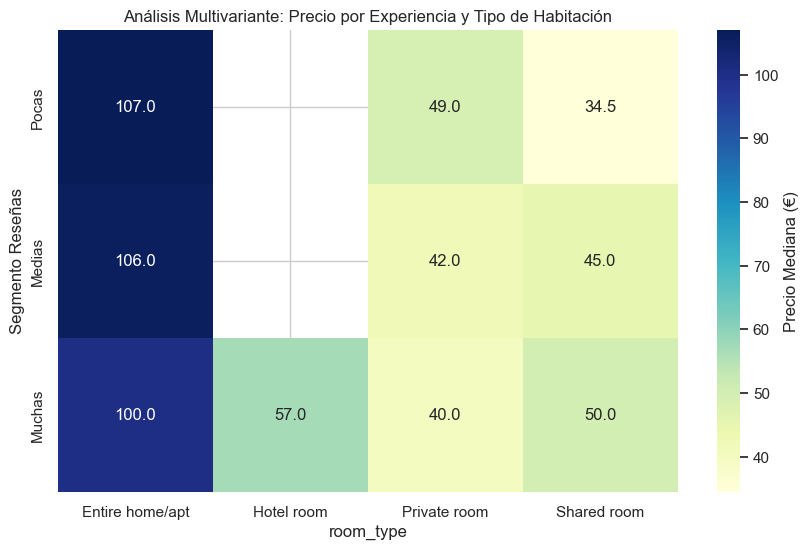

In [34]:
# Analizamos la mediana de precio cruzando Experiencia y Tipo de alojamiento
df_multi = df.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().unstack()

# Lo visualizamos con un mapa de calor (Heatmap) para que se entienda al momento
plt.figure(figsize=(10, 6))
sns.heatmap(df_multi, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Precio Mediana (€)'})
plt.title('Análisis Multivariante: Precio por Experiencia y Tipo de Habitación')
plt.show()

El análisis multivariante revela que la hipótesis se confirma de forma sólida en los segmentos principales del mercado (Apartamentos completos y Habitaciones privadas), donde el precio mediano desciende conforme aumenta el número de reseñas.

Sin embargo, se ha detectado una excepción significativa en las Habitaciones compartidas, donde la tendencia se invierte: los alojamientos con más reseñas son más caros (50€) que los nuevos (34.5€). Esto sugiere que en el segmento 'low-cost', la confianza generada por las reseñas es un activo que permite subir el precio, a diferencia del resto del mercado donde los nuevos anuncios parecen entrar con precios de prueba superiores a la media.

## Conclusión 

La hipótesis es válida para el grueso del mercado (casas y cuartos privados), pero no para los compartidos. Además, esposible que los alojamientos con pocas reseñas presenten precios más altos porque están disponibles en fechas de alta demanda (cuando los baratos ya se han reservado), lo que hace que su "precio medio" parezca más alto.